# Analysis of vegetation change in Everglades National Park between 2000 and 2024

The Everglades National Park is a vast subtropical wilderness in southern 
Florida, where freshwater and saltwater habitats merge to form a rich and 
diverse ecosystem. The park protects the southern approximaltly tewenty percent 
of the Everglades in Florida, covering an area of approximatly 1.5 million
acres of sawgrass marshes, cypress swamps, hardwood hammokcs, pine rocklands, 
and extensive mangrove forests ([National Park Service, U.S. Department of the Interior](https://www.npshistory.com/publications/ever/brochures/2015.pdf)). 




Some text will follow

In [1]:
# packages
# file structure
import os
import pathlib
import glob
# vector and raster data
import geopandas as gpd
import pandas as pd
import rioxarray as rxr
import xarray as xr
# arrays
import numpy as np
# plotting
import holoviews as hv
import hvplot.pandas
import hvplot.xarray
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
# open street map
from osmnx import features as osm
import osmnx as ox
# earthpy
import earthpy
import earthpy.api.appeears as eaapp

In [2]:
# Set up a project and folder for data using earthpy
project = earthpy.Project("Everglades Vegetation", dirname = 'ndvi_project')

In [3]:
# Search for Everglades Natironal Park using OpenStreetMaps
everglades_gdf = ox.geocode_to_gdf(
    'Everglades National Park')

# Check it out
everglades_gdf

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-81.52053 25.83264, -81.52048 25.818...",-81.520526,24.851129,-80.388994,25.891513,416088476,relation,2163707,25.367944,-80.878307,boundary,protected_area,25,0.540428,protected_area,Everglades National Park,"Everglades National Park, Florida, 34138, Unit..."


<Axes: >

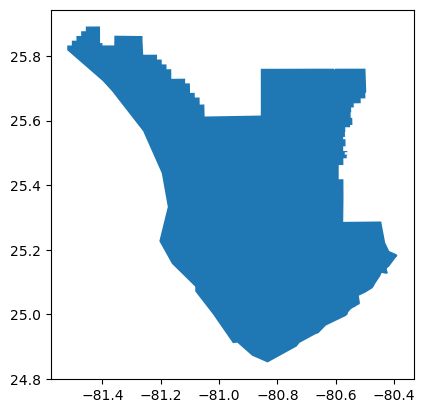

In [4]:
# Make a plot of the boundary
everglades_gdf.plot()

In [17]:
# Initialize AppeearsDownloader for MODIS NDVI data
# Set parameters
ndvi_downloader = eaapp.AppeearsDownloader(

    # Give the download a name
    download_key = "everglades_ndvi",

    # Tell it to put the data in the project directory already defined
    project = project,

    # Specify the MODIS product
    product = 'MOD13Q1.061',
    layer = '_250m_16_days_NDVI',

    # Set a start date and end data
    start_date = "04-01",
    end_date = "09-30",

    # Recurring meaning we want to download those dates over multiple years
    recurring = True,

    # Specify the range of years of interest
    year_range = [2000, 2024],

    # Specify the polygon we want to get NDVI data for
    polygon = everglades_gdf
)

In [18]:
# Download the prepared download
ndvi_downloader.download_files(cache=True)

Credentials found using 'env' backend.


In [5]:
# Get a sorted list of NDVI file paths
ndvi_paths = sorted(list(project.project_dir.rglob('*NDVI*.tif')))

# View the paths
ndvi_paths

[PosixPath('/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2000081000000_aid0001.tif'),
 PosixPath('/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2000097000000_aid0001.tif'),
 PosixPath('/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2000113000000_aid0001.tif'),
 PosixPath('/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2000129000000_aid0001.tif'),
 PosixPath('/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2000145000000_aid0001.tif'),
 PosixPath('/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2000161000000_aid0001.tif'),
 PosixPath('/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274

In [6]:
everglades_gdf.hvplot(
    geo=True, tiles='EsriImagery', 
    frame_width=500,
    legend=False, 
    fill_color=None, 
    line_color='white',
    title='Everglades National Park',
    )

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [7]:
doy_start = -25         # -25 to -22 is the year
doy_end = -18           # -21 to -19 is the day of the year

# Loop through each NDVI image
ndvi_das = []
for ndvi_path in ndvi_paths:

    # Get date from file name
    doy = ndvi_path.name[doy_start:doy_end]
    # doy is a string of year + day of the year 
    date = pd.to_datetime(doy, format="%Y%j")
    # Open dataset

    data = rxr.open_rasterio(ndvi_path, mask_and_scale=True).squeeze()

    # Add date dimension and clean up metadata
    data = data.assign_coords({'date': date})
    data = data.expand_dims({'date': 1})
    data.name = 'NDVI'

    # Prepare for concatenation
    ndvi_das.append(data)

### Combine Rasters
stack arrays by date into a time series using the
`xr.combine_by_coords()` function. 
The dimension for stacking is date

In [8]:
# Combine NDVI images from all dates
ndvi_da = xr.combine_by_coords(ndvi_das, coords = ['date'])
ndvi_da

/tmp/ipykernel_27740/1027227971.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das, coords = ['date'])
/tmp/ipykernel_27740/1027227971.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das, coords = ['date'])


<xarray.Dataset> Size: 354MB
Dimensions:      (date: 325, y: 500, x: 544)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 4kB -81.52 -81.52 -81.52 ... -80.39 -80.39 -80.39
  * y            (y) float64 4kB 25.89 25.89 25.89 25.88 ... 24.86 24.85 24.85
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 3kB 2000-03-21 2000-04-06 ... 2024-09-29
Data variables:
    NDVI         (date, y, x) float32 354MB 0.5234 0.1257 0.1257 ... nan nan nan

In [28]:
august_data = ndvi_da.sel(date=ndvi_da.date.dt.month == 9)

In [29]:
august_data

<xarray.Dataset> Size: 54MB
Dimensions:      (date: 50, y: 500, x: 544)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 4kB -81.52 -81.52 -81.52 ... -80.39 -80.39 -80.39
  * y            (y) float64 4kB 25.89 25.89 25.89 25.88 ... 24.86 24.85 24.85
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 400B 2000-09-13 2000-09-29 ... 2024-09-29
Data variables:
    NDVI         (date, y, x) float32 54MB 0.3694 0.395 0.5093 ... nan nan nan

In [30]:
ndvi_da_annual = ndvi_da.groupby('date.year').mean()

In [31]:
ndvi_da_annual

<xarray.Dataset> Size: 27MB
Dimensions:      (year: 25, y: 500, x: 544)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 4kB -81.52 -81.52 -81.52 ... -80.39 -80.39 -80.39
  * y            (y) float64 4kB 25.89 25.89 25.89 25.88 ... 24.86 24.85 24.85
    spatial_ref  int64 8B 0
  * year         (year) int64 200B 2000 2001 2002 2003 ... 2021 2022 2023 2024
Data variables:
    NDVI         (year, y, x) float32 27MB 0.5187 0.3859 0.3365 ... nan nan nan

###  First plots 
First, we compare an NDVI image from the earliest year on record with the 
latest year on record. To enable a better comparison, we select the same 
day of the year in each year.

In [32]:
print(ndvi_paths[5])
print(ndvi_paths[-8])

/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2000161000000_aid0001.tif
/workspaces/data/ndvi_project/everglades_ndvi/MOD13Q1.061_1990076_to_2024274/MOD13Q1.061__250m_16_days_NDVI_doy2024161000000_aid0001.tif


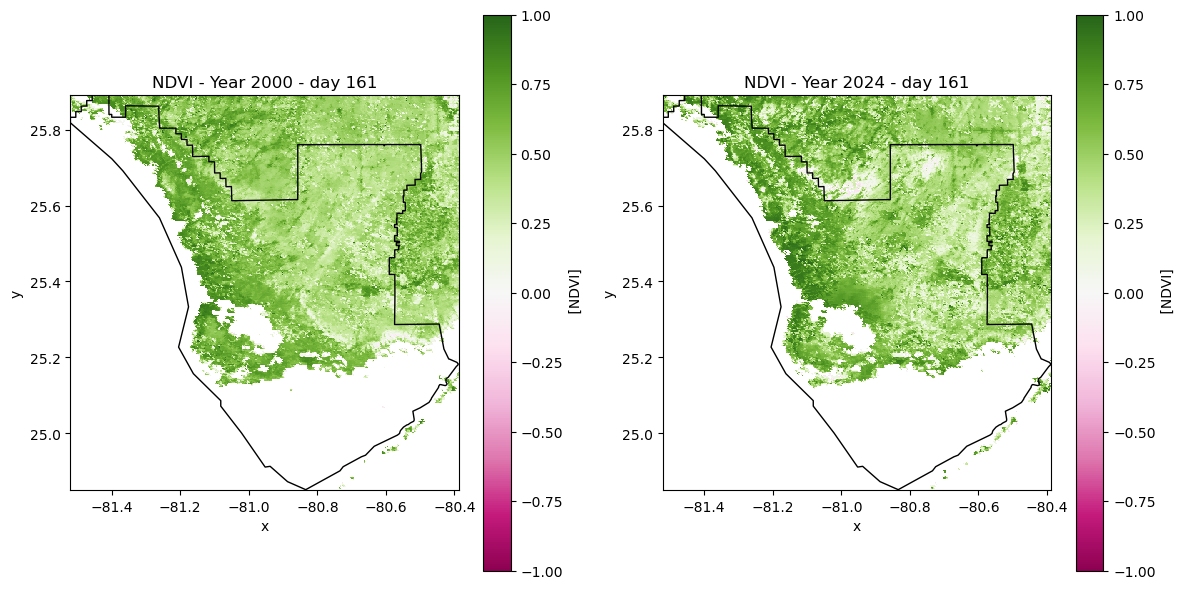

In [15]:
# plot them side by side
ndvi_first = rxr.open_rasterio(ndvi_paths[5], mask_and_scale = True).squeeze()
ndvi_last = rxr.open_rasterio(ndvi_paths[-8], mask_and_scale = True).squeeze()

# make side by side subplots
# 1 subplot with 1 row + 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# plot first ndvi with gila river boundary
ndvi_first.plot(ax=axes[0], cmap=plt.cm.PiYG, vmin=-1, vmax=1)
everglades_gdf.plot(ax=axes[0], edgecolor='black', facecolor='none', linewidth=1)
axes[0].set_title("NDVI - Year 2000 - day 161")

# plot last ndvi with gila river boundary
ndvi_last.plot(ax=axes[1], cmap=plt.cm.PiYG, vmin=-1, vmax=1)
everglades_gdf.plot(ax=axes[1], edgecolor='black', facecolor='none', linewidth=1)
axes[1].set_title("NDVI - Year 2024 - day 161")

# play with layout
plt.tight_layout()
plt.show()

### Clacualte and plot difference maps

The next step is to calcualte and plot the differecne in NDVI in our dataset.
We split the Dataset in two time periods 2000-2011 and 2012 to 2024. 

In [17]:
#ndvi_data_2000_2012 = ndvi_da_annual.sel(year=slice('2000', '2012')).mean('year').NDVI
#ndvi_data_2013_2024 = ndvi_da_annual.sel(year=slice('2013', '2024')).mean('year').NDVI

ndvi_data_2000_2012 = august_data.sel(date=slice('2000', '2012')).mean('date').NDVI
ndvi_data_2013_2024 = august_data.sel(date=slice('2013', '2024')).mean('date').NDVI

In [18]:
# Compute the difference in NDVI before and after
ndvi_diff = (
    ndvi_data_2013_2024 
    - 
    ndvi_data_2000_2012
)


# Plot the difference
(
    ndvi_diff.hvplot(x='x', y='y', cmap='PiYG', geo=True,
                     title = "NDVI changes in Everglades National Park\nfrom 2000-2012 to 2013-2024")
    *
    everglades_gdf.hvplot(geo=True, fill_color=None, line_color='black')
)

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

<Axes: >

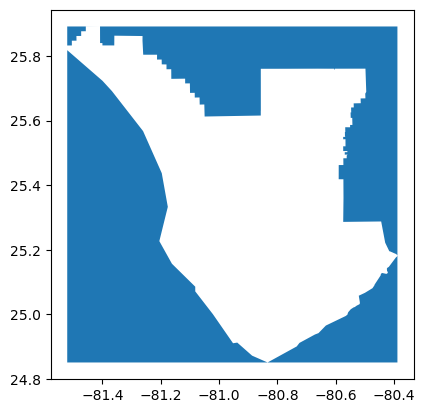

In [19]:
# Compute the area outside the Gila River Indian Community
non_everglades_gdf = (
    gpd.GeoDataFrame(geometry=everglades_gdf.envelope)
    .overlay(everglades_gdf, how='difference')
)

# Plot the outside Gila gdf
non_everglades_gdf.plot()

In [22]:
# Clip data to inside the boundary
ndvi_inside = august_data.rio.clip(everglades_gdf.geometry, from_disk=True)
ndvi_inside

# Clip data to outside the boundary
ndvi_outside = august_data.rio.clip(non_everglades_gdf.geometry, from_disk=True)
ndvi_outside

<xarray.Dataset> Size: 54MB
Dimensions:      (x: 543, y: 499, date: 50)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 4kB -81.52 -81.52 -81.52 ... -80.39 -80.39 -80.39
  * y            (y) float64 4kB 25.89 25.89 25.89 25.88 ... 24.86 24.86 24.85
  * date         (date) datetime64[ns] 400B 2000-08-12 2000-08-28 ... 2024-08-28
    spatial_ref  int64 8B 0
Data variables:
    NDVI         (date, y, x) float32 54MB 0.5421 0.2814 0.4473 ... nan nan nan

In [24]:
# Compute mean annual July NDVI
# inside 
august_ndvi_inside_df = (ndvi_inside
                       .groupby(ndvi_inside.date.dt.year) # group by year
                       .mean(...) # get mean NDVI
                       .NDVI
                       .to_dataframe()) # convert data to a dataframe
august_ndvi_inside_df.head()

# outside 
august_ndvi_outside_df = (ndvi_outside
                       .groupby(ndvi_inside.date.dt.year) # group by year
                       .mean(...) # get mean NDVI
                       .NDVI
                       .to_dataframe()) # convert data to a dataframe
august_ndvi_outside_df.head()

,band,spatial_ref,NDVI
year,,,
2000,1,0,0.484295
2001,1,0,0.487510
2002,1,0,0.455708
2003,1,0,0.448866
2004,1,0,0.476522


In [25]:
# Join inside and outside DataFrames and rename/add suffix to column names
august_ndvi_df = (
            august_ndvi_inside_df[['NDVI']]           # NDVI data from for the first DataFrame
            .join(august_ndvi_outside_df[['NDVI']],   # NDVI from the second DataFrame
            lsuffix='_inside',                      # rename first 
            rsuffix='_outside'))                    # rename second 
august_ndvi_df

,NDVI_inside,NDVI_outside
year,,
2000,0.508618,0.484295
2001,0.520896,0.487510
2002,0.502491,0.455708
2003,0.493523,0.448866
2004,0.529052,0.476522
2005,0.500266,0.471779
2006,0.511497,0.489866
2007,0.550211,0.489184
2008,0.483061,0.456507


In [26]:
### calculate the difference
august_ndvi_df['difference'] = (august_ndvi_df['NDVI_inside']
                              - august_ndvi_df['NDVI_outside'])

august_ndvi_df

,NDVI_inside,NDVI_outside,difference
year,,,
2000,0.508618,0.484295,0.024324
2001,0.520896,0.487510,0.033386
2002,0.502491,0.455708,0.046783
2003,0.493523,0.448866,0.044657
2004,0.529052,0.476522,0.052530
2005,0.500266,0.471779,0.028487
2006,0.511497,0.489866,0.021631
2007,0.550211,0.489184,0.061027
2008,0.483061,0.456507,0.026554


In [27]:
# Plot mean NDVI inside and outside the boundary
august_ndvi_df.hvplot(title = "Mean August NDVI inside and outside GRIC")

:NdOverlay   [Variable]
   :Curve   [year]   (value)